# Walsh Coefficient Visualization (4 Plots)

This notebook builds four visuals: a linkage network graph, a pairwise heatmap, per-order magnitude distribution, and a top-20 feature-importance bar chart.

## 1. Load Data and Parse Indices

Load the CSV, parse the index lists, and compute absolute coefficients.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

csv_path = "../nk_walsh_coefficients.csv"
df = pd.read_csv(csv_path)

def parse_indices(value):
    if pd.isna(value) or str(value).strip() == "":
        return []
    return [int(x) for x in str(value).split(";") if x]

df["indices_list"] = df["indices"].apply(parse_indices)
df["abs_coefficient"] = df["coefficient"].abs()

indices_flat = df["indices_list"].explode()
indices_flat = indices_flat.dropna().astype(int)
max_index = indices_flat.max() if not indices_flat.empty else -1
n_vars = int(max_index) + 1 if max_index >= 0 else 0

df.head()

,order,indices,coefficient,indices_list,abs_coefficient
0,0,NaN,0.498435,[],0.498435
1,1,602,-0.000611,[602],0.000611
2,1,499,0.000605,[499],0.000605
3,1,708,-0.000577,[708],0.000577
4,1,22,0.000540,[22],0.000540


## 3. Magnitude Distribution by Order (1-3)

Compare the absolute coefficient distributions for orders 1, 2, and 3 to see how higher-order terms decay.

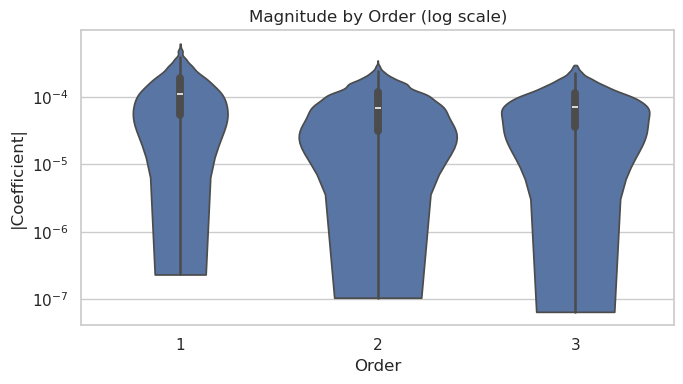

In [8]:
orders = [1, 2, 3]
plot_df = df[df["order"].isin(orders)].copy()

if plot_df.empty:
    raise ValueError("No coefficients found for orders 1-3.")

plt.figure(figsize=(7, 4))
sns.violinplot(data=plot_df, x="order", y="abs_coefficient", inner="box", cut=0)
plt.yscale("log")
plt.title("Magnitude by Order (log scale)")
plt.xlabel("Order")
plt.ylabel("|Coefficient|")
plt.tight_layout()
plt.show()

## 4. Top-10 Feature Importance per Order

Rank the largest absolute coefficients within each order and plot them as separate horizontal bar charts.

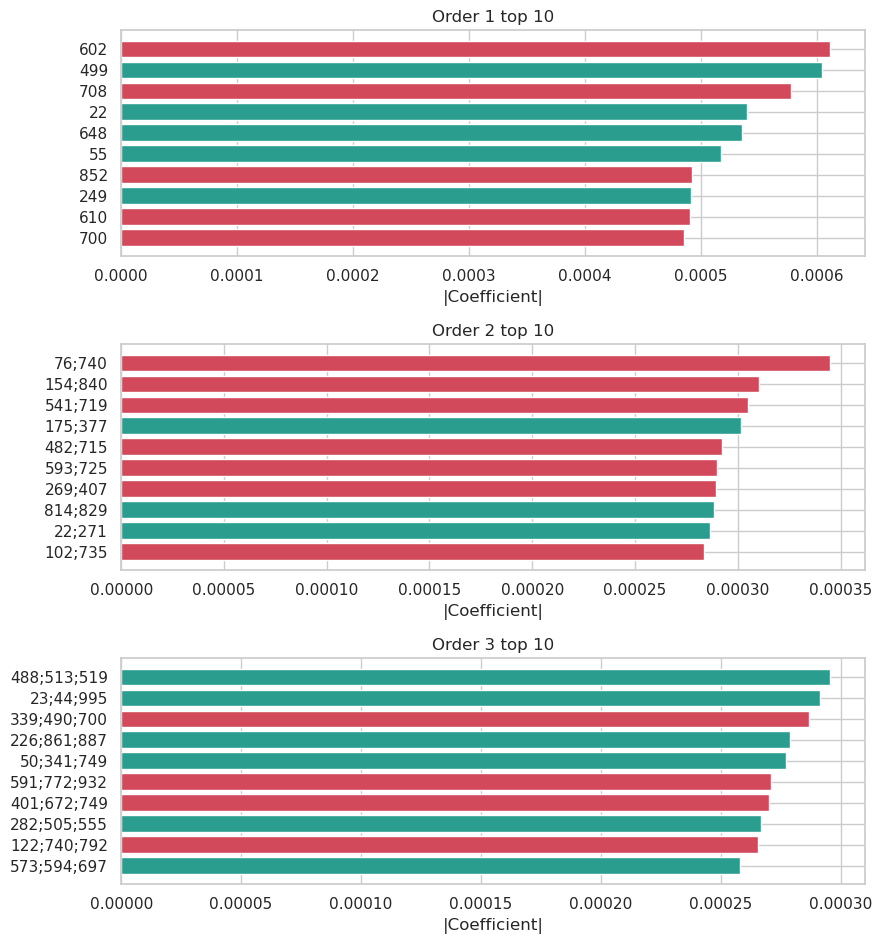

In [10]:
def make_label(row):
    raw_idx = row["indices"]
    idx = raw_idx if pd.notna(raw_idx) and str(raw_idx).strip() != "" else "intercept"
    return str(idx)

top_k = 10
orders = sorted(o for o in df["order"].unique() if o > 0)

if not orders:
    raise ValueError("No coefficients found for orders >= 1.")

rows = len(orders)
fig, axes = plt.subplots(rows, 1, figsize=(9, 3.2 * rows), sharex=False)
if rows == 1:
    axes = [axes]

for ax, order in zip(axes, orders):
    subset = df[df["order"] == order].copy()
    if subset.empty:
        ax.axis("off")
        ax.set_title(f"Order {order} (no data)")
        continue

    subset["label"] = subset.apply(make_label, axis=1)
    subset = subset.nlargest(top_k, "abs_coefficient").sort_values("abs_coefficient")
    colors = ["#d1495b" if val < 0 else "#2a9d8f" for val in subset["coefficient"]]

    ax.barh(subset["label"], subset["abs_coefficient"], color=colors)
    ax.set_title(f"Order {order} top {top_k}")
    ax.set_xlabel("|Coefficient|")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()